## Grid Search for Bipartite Hyperparameters

This notebook performs a grid search to find the best hyperparameters for the bipartite word-alignment model. We evaluate the (α, λ, lexical-normalization) combinations on each manually annotated ground-truth set independently — one section per (region × ASR-model) combination — and select the combination that yields the highest mean alignment accuracy.

In [17]:
import sys
import json
import numpy as np

sys.path.insert(0, "domain")
sys.path.insert(0, "utils")

# hyperparameters to search over
alphas = np.linspace(0, 1, 21)  # lexical vs. positional weight (1 = lexical only)
lambdas = np.linspace(0, 1, 21)  # epsilon penalty (0 = no penalty, 1 = max penalty)
lexical_normalization_modes = [False, True]  # use global or local lexical normalization

print(f"Alpha:  {len(alphas)} values, range [{alphas[0]:.2f}, {alphas[-1]:.2f}]")
print(f"Lambda: {len(lambdas)} values, range [{lambdas[0]:.2f}, {lambdas[-1]:.2f}]")
print(f"Total combinations: {len(alphas) * len(lambdas) * len(lexical_normalization_modes):,}")

Alpha:  21 values, range [0.00, 1.00]
Lambda: 21 values, range [0.00, 1.00]
Total combinations: 882


In [18]:
from grid_search_bipartite_hyperparameters import (
    grid_search, pivot_accuracy_grids, print_best_accuracy_summary,
)
from plot_helpers import plot_grid_search_heatmaps

GT_DIR = "../experiments/hyperparameter_tuning"


def load_ground_truth(path):
    with open(path, encoding="utf-8-sig") as f:
        entries = json.load(f)
    for entry in entries:
        entry["alignment"] = {int(k): v for k, v in entry["alignment"].items()}
    return entries


def run_grid_search(gt_filename, label):
    entries = load_ground_truth(f"{GT_DIR}/{gt_filename}")
    print(f"{label}: {len(entries)} entries")
    df = grid_search(entries, alphas, lambdas, lexical_normalization_modes)
    accuracy_grids = pivot_accuracy_grids(df)

    plot_grid_search_heatmaps(
        panels=[(accuracy_grids[mode], f"use_global_lexical_normalization={mode}") for mode in lexical_normalization_modes],
        alphas=alphas,
        lambdas=lambdas,
        subtitle=f"Grid Search: Mean Accuracy ({label})",
    )
    for mode in lexical_normalization_modes:
        subset = df[df["use_global_lexical_normalization"] == mode]
        print_best_accuracy_summary(subset, f"use_global_lexical_normalization={mode}: ")
    return df

## Wallis DIT

Wallis DIT: 100 entries


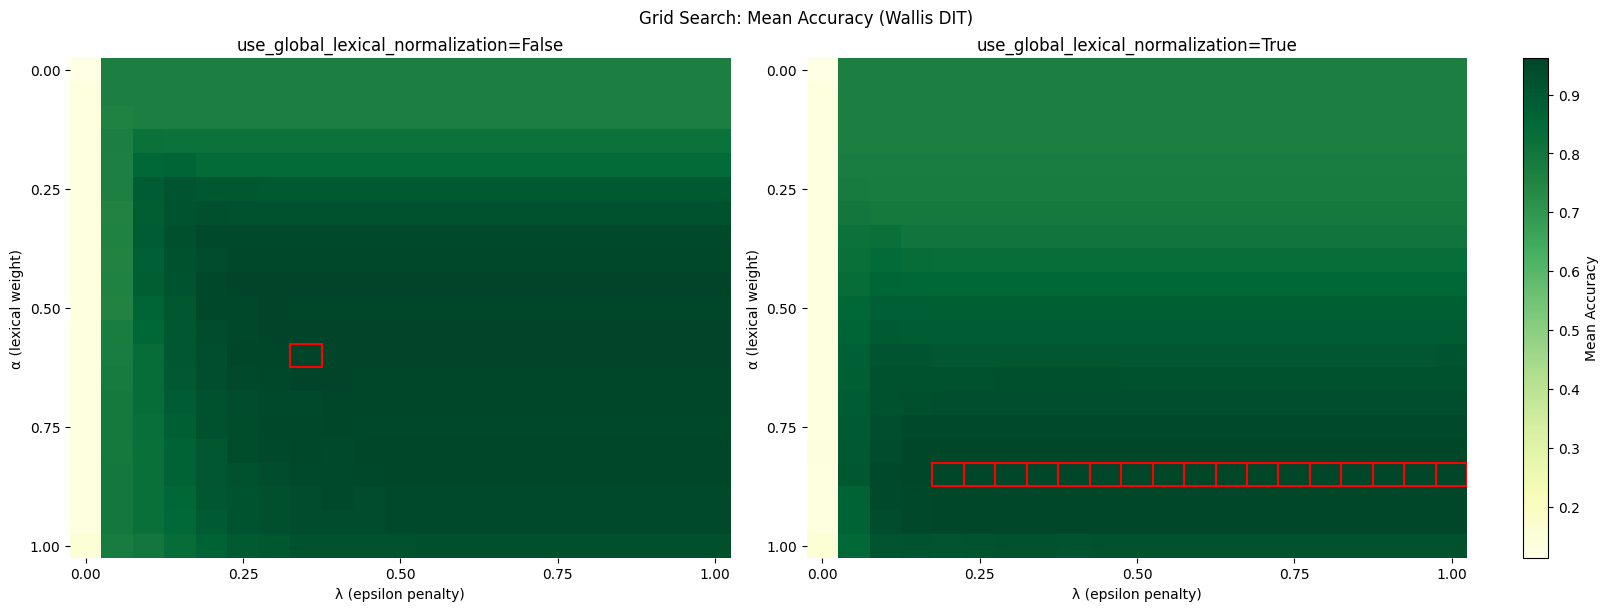

use_global_lexical_normalization=False: Best accuracy = 0.962 (1 tied)
  α tied: ['0.60']
  λ tied: ['0.35']
use_global_lexical_normalization=True: Best accuracy = 0.956 (17 tied)
  α tied: ['0.85']
  λ tied: ['0.20', '0.25', '0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']


In [19]:
df_wallis_dit = run_grid_search("samples_ground_truth_alignments_wallis_dit.json", "Wallis DIT")

## Wallis DAT

Wallis DAT: 100 entries


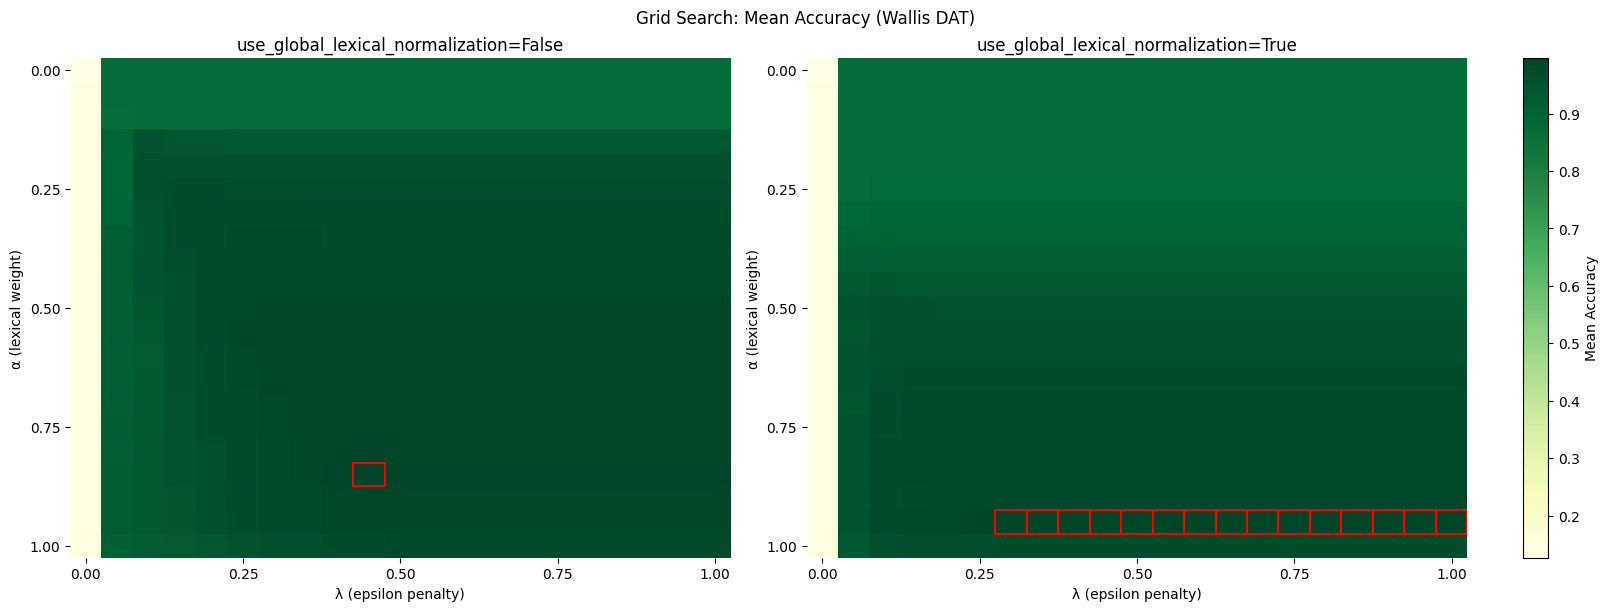

use_global_lexical_normalization=False: Best accuracy = 0.997 (1 tied)
  α tied: ['0.85']
  λ tied: ['0.45']
use_global_lexical_normalization=True: Best accuracy = 0.988 (15 tied)
  α tied: ['0.95']
  λ tied: ['0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']


In [20]:
df_wallis_dat = run_grid_search("samples_ground_truth_alignments_wallis_dat.json", "Wallis DAT")

## Zürich DIT

Zürich DIT: 100 entries


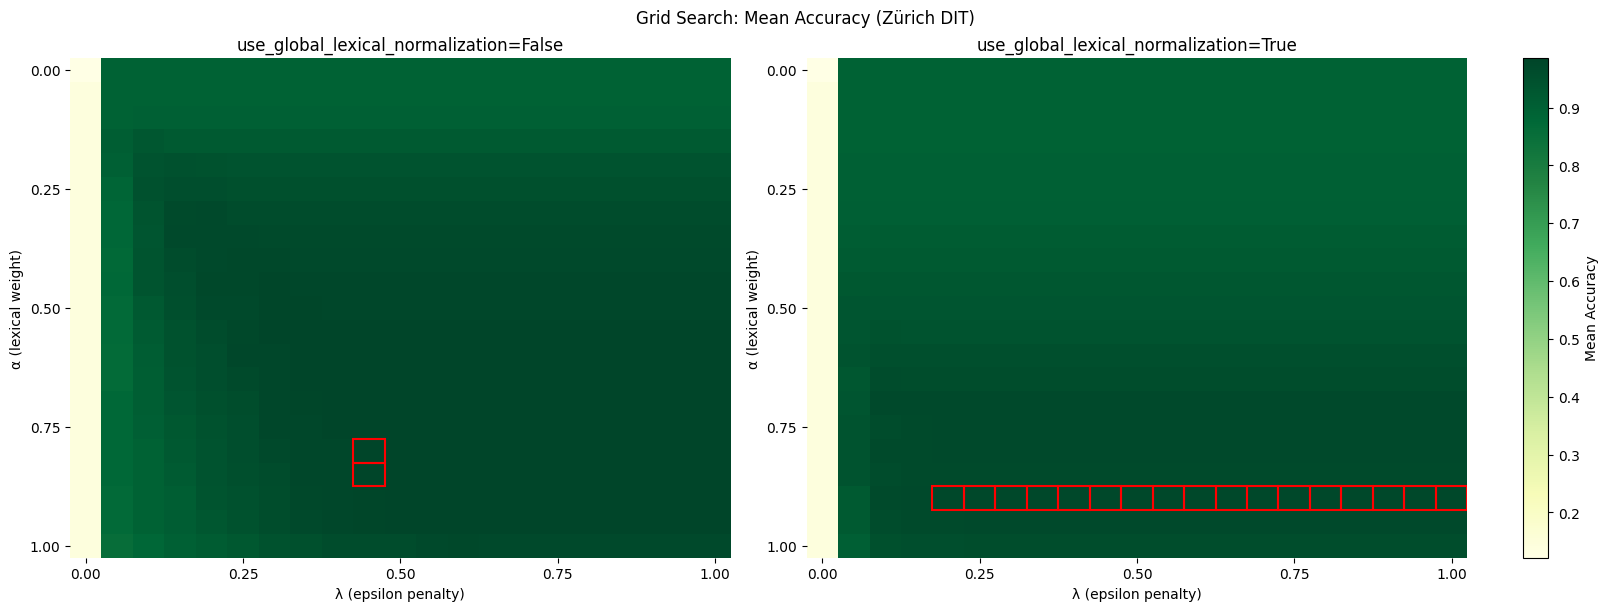

use_global_lexical_normalization=False: Best accuracy = 0.986 (2 tied)
  α tied: ['0.80', '0.85']
  λ tied: ['0.45']
use_global_lexical_normalization=True: Best accuracy = 0.973 (17 tied)
  α tied: ['0.90']
  λ tied: ['0.20', '0.25', '0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']


In [21]:
df_zurich_dit = run_grid_search("samples_ground_truth_alignments_zurich_dit.json", "Zürich DIT")

## Zürich DAT

Zürich DAT: 100 entries


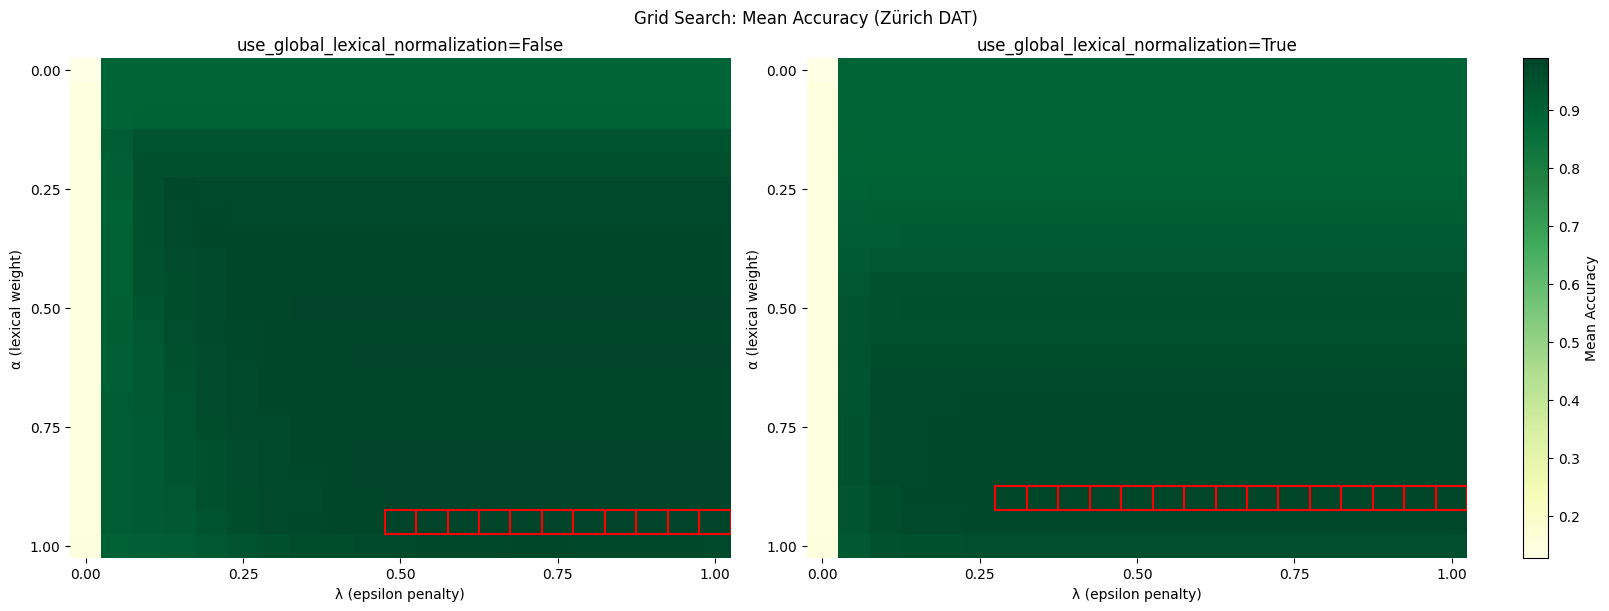

use_global_lexical_normalization=False: Best accuracy = 0.990 (11 tied)
  α tied: ['0.95']
  λ tied: ['0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']
use_global_lexical_normalization=True: Best accuracy = 0.980 (15 tied)
  α tied: ['0.90']
  λ tied: ['0.30', '0.35', '0.40', '0.45', '0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90', '0.95', '1.00']


In [22]:
df_zurich_dat = run_grid_search("samples_ground_truth_alignments_zurich_dat.json", "Zürich DAT")